
=== PrimeVul | Within-Project: linux | SMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (linux): (43212, 768)  vuln=1002  benign=42210
      Test  (linux): (4140, 768)  vuln=70  benign=4070
      Train imbalance ratio: 0.0232

[2/6] Normalising embeddings...

[3/6] Applying SMOTE...
      Before SMOTE — benign: 42210 | vuln: 1002 | ratio: 42.13
      After  SMOTE — benign: 42210 | vuln: 42210 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-SMOTE): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6125
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.5758
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.5289
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.4691
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.4177
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.3845
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.3544
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.3342
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.3176
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.2998
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.2836
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.2703
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.2583
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.2448
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.2339
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.2206
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6062
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.5780
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.5360
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.4847
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.4348
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.3969
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.3695
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.3480
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.3290
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.3142
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.3000
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.2864
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.2765
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.2622
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.2490
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.2372
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.5990
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.5580
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.5025
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.4367
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.3897
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.3563
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.3331
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.3118
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.2934
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.2766
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.2609
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.2442
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.2311
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.2254
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.2051
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.1962
 

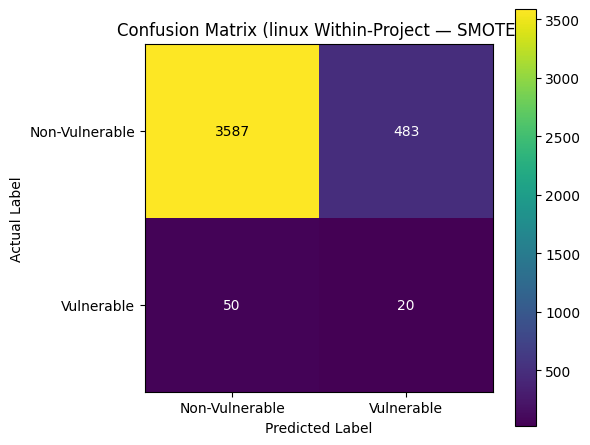

In [2]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on linux (train split) -> Test on linux (test split)
SMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "linux"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/smote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, criterion, epochs, desc,
                         class_weights):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (nn.BCELoss(reduction='none')(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (nn.BCELoss(reduction='none')(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, None,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project",
        class_weights=class_weights
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to linux only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    smote = SMOTE(random_state=SEED)
    train_emb_res, train_lbl_res = smote.fit_resample(train_emb, train_lbl)
    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"         : "smote_within_project",
        "setting"            : "within_project",
        "project"            : PROJECT,
        "n_train_before_smote": int(len(train_lbl)),
        "n_train_after_smote" : int(len(train_lbl_res)),
        "n_vuln_before_smote" : n_pos_before,
        "n_benign_before_smote": n_neg_before,
        "n_vuln_after_smote"  : n_pos_after,
        "n_benign_after_smote": n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),       4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"smote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_smote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: tensorflow | SMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (tensorflow): (1089, 768)  vuln=76  benign=1013
      Test  (tensorflow): (1313, 768)  vuln=91  benign=1222
      Train imbalance ratio: 0.0698

[2/6] Normalising embeddings...

[3/6] Applying SMOTE...
      Before SMOTE — benign: 1013 | vuln: 76 | ratio: 13.33
      After  SMOTE — benign: 1013 | vuln: 1013 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-SMOTE): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6909
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6893
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6877
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6860
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6842
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6823
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6801
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6776
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6745
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6709
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6666
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6621
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6568
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6509
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6444
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6374
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6966
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6947
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6931
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6916
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6902
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6887
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6868
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6846
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6822
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6796
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6769
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6734
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6693
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6645
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6590
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6527
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6927
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6917
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6905
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6889
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6869
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6847
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6822
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6791
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6751
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6701
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6639
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6567
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6481
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6384
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6271
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6147
 

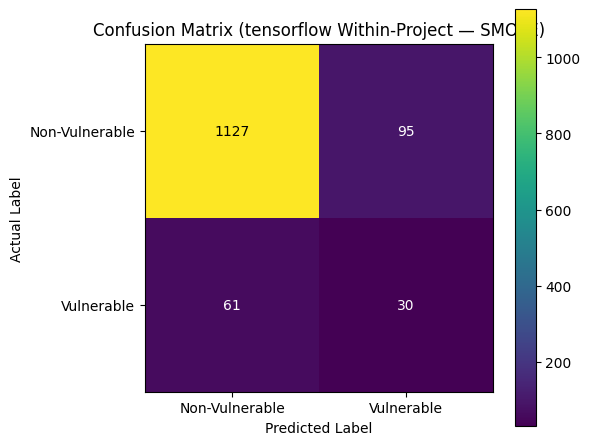

In [3]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on tensorflow (train split) -> Test on tensorflow (test split)
SMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "tensorflow"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/smote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, criterion, epochs, desc,
                         class_weights):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (nn.BCELoss(reduction='none')(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (nn.BCELoss(reduction='none')(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, None,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project",
        class_weights=class_weights
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to tensorflow only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    smote = SMOTE(random_state=SEED)
    train_emb_res, train_lbl_res = smote.fit_resample(train_emb, train_lbl)
    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"         : "smote_within_project",
        "setting"            : "within_project",
        "project"            : PROJECT,
        "n_train_before_smote": int(len(train_lbl)),
        "n_train_after_smote" : int(len(train_lbl_res)),
        "n_vuln_before_smote" : n_pos_before,
        "n_benign_before_smote": n_neg_before,
        "n_vuln_after_smote"  : n_pos_after,
        "n_benign_after_smote": n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),       4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"smote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_smote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: vim | SMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (vim): (951, 768)  vuln=38  benign=913
      Test  (vim): (1669, 768)  vuln=61  benign=1608
      Train imbalance ratio: 0.0400

[2/6] Normalising embeddings...

[3/6] Applying SMOTE...
      Before SMOTE — benign: 913 | vuln: 38 | ratio: 24.03
      After  SMOTE — benign: 913 | vuln: 913 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-SMOTE): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6926
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6914
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6904
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6894
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6884
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6874
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6860
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6844
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6824
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6800
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6774
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6745
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6713
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6678
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6640
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6602
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.7016
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.7005
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6994
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6982
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6971
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6960
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6950
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6940
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6926
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6910
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6890
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6864
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6835
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6804
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6772
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6738
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6928
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6921
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6913
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6903
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6890
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6874
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6856
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6837
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6813
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6786
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6753
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6715
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6670
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6622
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6568
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6509
 

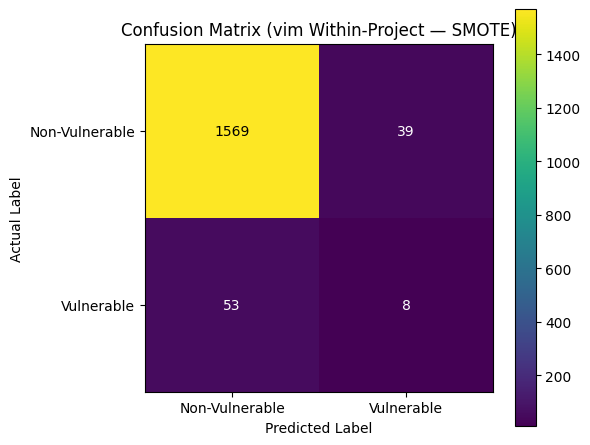

In [4]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on vim (train split) -> Test on vim (test split)
SMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "vim"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/smote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, criterion, epochs, desc,
                         class_weights):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (nn.BCELoss(reduction='none')(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (nn.BCELoss(reduction='none')(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, None,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project",
        class_weights=class_weights
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to vim only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    smote = SMOTE(random_state=SEED)
    train_emb_res, train_lbl_res = smote.fit_resample(train_emb, train_lbl)
    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"         : "smote_within_project",
        "setting"            : "within_project",
        "project"            : PROJECT,
        "n_train_before_smote": int(len(train_lbl)),
        "n_train_after_smote" : int(len(train_lbl_res)),
        "n_vuln_before_smote" : n_pos_before,
        "n_benign_before_smote": n_neg_before,
        "n_vuln_after_smote"  : n_pos_after,
        "n_benign_after_smote": n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),       4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"smote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_smote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: gpac | SMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (gpac): (2775, 768)  vuln=32  benign=2743
      Test  (gpac): (1884, 768)  vuln=18  benign=1866
      Train imbalance ratio: 0.0115

[2/6] Normalising embeddings...

[3/6] Applying SMOTE...
      Before SMOTE — benign: 2743 | vuln: 32 | ratio: 85.72
      After  SMOTE — benign: 2743 | vuln: 2743 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-SMOTE): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6880
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6825
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6753
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6651
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6506
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6319
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6078
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.5803
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.5516
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.5235
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.4986
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.4779
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.4608
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.4485
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.4395
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.4328
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6939
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6902
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6842
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6764
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6650
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6472
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6223
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.5917
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.5590
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.5260
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.4968
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.4722
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.4550
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.4434
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.4355
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.4293
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6905
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6853
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6773
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6628
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6384
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6030
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.5621
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.5231
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.4914
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.4694
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.4541
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.4427
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.4332
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.4242
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.4123
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.3930
 

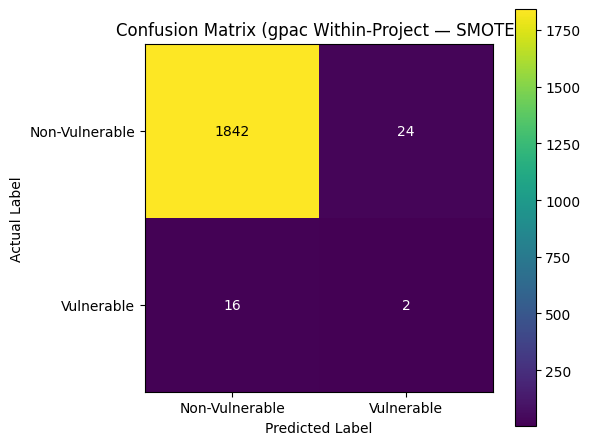

In [5]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on gpac (train split) -> Test on gpac (test split)
SMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "gpac"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/smote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, criterion, epochs, desc,
                         class_weights):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (nn.BCELoss(reduction='none')(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (nn.BCELoss(reduction='none')(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, None,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project",
        class_weights=class_weights
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to gpac only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    smote = SMOTE(random_state=SEED)
    train_emb_res, train_lbl_res = smote.fit_resample(train_emb, train_lbl)
    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"         : "smote_within_project",
        "setting"            : "within_project",
        "project"            : PROJECT,
        "n_train_before_smote": int(len(train_lbl)),
        "n_train_after_smote" : int(len(train_lbl_res)),
        "n_vuln_before_smote" : n_pos_before,
        "n_benign_before_smote": n_neg_before,
        "n_vuln_after_smote"  : n_pos_after,
        "n_benign_after_smote": n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),       4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"smote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_smote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: FreeRDP | SMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (FreeRDP): (872, 768)  vuln=23  benign=849
      Test  (FreeRDP): (26, 768)  vuln=1  benign=25
      Train imbalance ratio: 0.0264

[2/6] Normalising embeddings...

[3/6] Applying SMOTE...
      Before SMOTE — benign: 849 | vuln: 23 | ratio: 36.91
      After  SMOTE — benign: 849 | vuln: 849 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-SMOTE): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6899
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6887
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6877
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6867
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6857
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6846
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6833
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6818
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6802
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6784
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6764
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6742
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6717
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6689
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6658
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6622
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6907
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6896
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6886
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6874
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6861
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6849
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6839
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6828
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6816
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6803
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6789
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6773
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6755
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6735
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6711
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6687
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6932
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6925
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6918
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6909
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6898
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6884
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6867
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6850
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6829
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6805
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6776
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6744
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6707
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6662
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6611
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6553
 

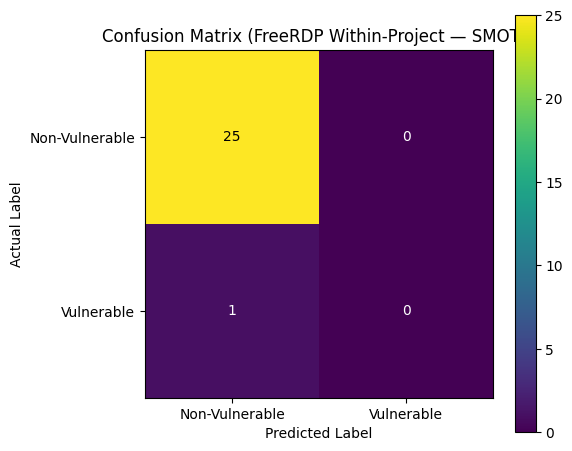

In [6]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on FreeRDP (train split) -> Test on FreeRDP (test split)
SMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "FreeRDP"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/smote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, criterion, epochs, desc,
                         class_weights):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (nn.BCELoss(reduction='none')(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (nn.BCELoss(reduction='none')(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, None,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project",
        class_weights=class_weights
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to FreeRDP only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    smote = SMOTE(random_state=SEED)
    train_emb_res, train_lbl_res = smote.fit_resample(train_emb, train_lbl)
    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"         : "smote_within_project",
        "setting"            : "within_project",
        "project"            : PROJECT,
        "n_train_before_smote": int(len(train_lbl)),
        "n_train_after_smote" : int(len(train_lbl_res)),
        "n_vuln_before_smote" : n_pos_before,
        "n_benign_before_smote": n_neg_before,
        "n_vuln_after_smote"  : n_pos_after,
        "n_benign_after_smote": n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy),  4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall),    4),
        "f1"                  : round(float(f1),        4),
        "auc"                 : round(float(auc),       4),
        "g_mean"              : round(float(g_mean),    4),
        "pf"                  : round(float(pf),        4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"smote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_smote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()